# EnergiAI - Modelo MVP (endpoint obrigatório do edital)

Este notebook cobre a análise do **Modelo MVP** — o modelo simplificado, criado só pra
atender exatamente ao formato de entrada/saída do endpoint obrigatório do edital:

```
POST /analise-energetica
Entrada: consumo_kwh, uso_horario_pico, quantidade_equipamentos, tipo_imovel, horas_alto_consumo
Saída: categoria, probabilidade, recomendacoes, custo_estimado_mensal
```

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

# reaproveita as funções do modelo principal -- não duplica lógica de carregar/limpar/construir a base
import treino_modelo as tm
import treino_modelo_mvp as tmm

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')

## 2. Construindo a base MVP


In [2]:
base_mvp = tmm.criar_base_mvp()
print(base_mvp.shape)
base_mvp.head(10)

(1000, 6)


,consumo_kwh,uso_horario_pico,quantidade_equipamentos,tipo_imovel,horas_alto_consumo,perfil_energetico
0,1220,True,7,Residencial,9,Moderado
1,2120,False,12,Residencial,7,Moderado
2,4485,True,50,Comercial,10,Moderado
3,15216,True,67,Comercial,10,Ineficiente
4,3067,False,26,Comercial,6,Eficiente
5,13373,False,80,Comercial,6,Ineficiente
6,6142,False,54,Comercial,6,Moderado
7,4379,False,39,Comercial,6,Moderado
8,4966,True,16,Residencial,8,Ineficiente
9,559,False,11,Residencial,8,Eficiente


In [3]:
base_mvp.describe(include='all')

,consumo_kwh,uso_horario_pico,quantidade_equipamentos,tipo_imovel,horas_alto_consumo,perfil_energetico
count,1000.000000,1000,1000.000000,1000,1000.000000,1000
unique,NaN,2,NaN,3,NaN,3
top,NaN,False,NaN,Residencial,NaN,Moderado
freq,NaN,611,NaN,570,NaN,445
mean,4442.179000,NaN,25.367000,NaN,7.733000,NaN
std,5008.945345,NaN,19.457978,NaN,2.544049,NaN
min,42.000000,NaN,3.000000,NaN,3.000000,NaN
25%,1448.750000,NaN,11.000000,NaN,6.000000,NaN
50%,3137.500000,NaN,16.000000,NaN,8.000000,NaN
75%,5551.250000,NaN,40.000000,NaN,9.000000,NaN


## 3. EDA — os 5 campos do edital

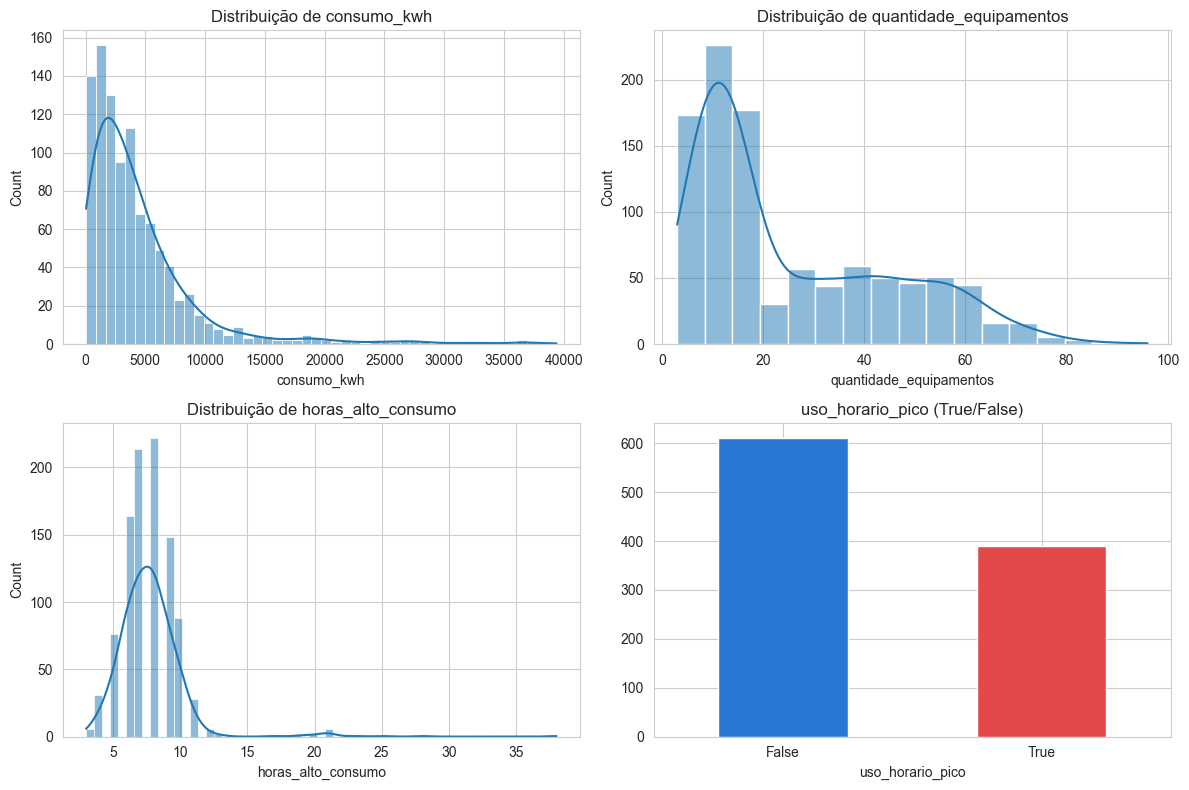

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(base_mvp['consumo_kwh'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribuição de consumo_kwh')

sns.histplot(base_mvp['quantidade_equipamentos'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribuição de quantidade_equipamentos')

sns.histplot(base_mvp['horas_alto_consumo'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribuição de horas_alto_consumo')

base_mvp['uso_horario_pico'].value_counts().plot(kind='bar', ax=axes[1,1], color=['#2a78d6','#e34948'])
axes[1,1].set_title('uso_horario_pico (True/False)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

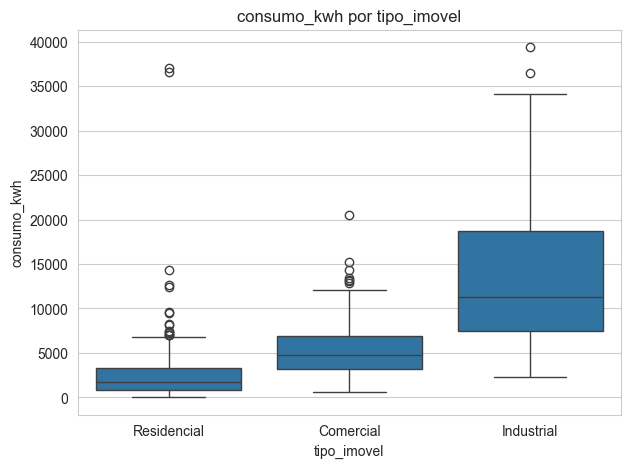

In [5]:
plt.figure(figsize=(7,5))
sns.boxplot(data=base_mvp, x='tipo_imovel', y='consumo_kwh')
plt.title('consumo_kwh por tipo_imovel')
plt.show()

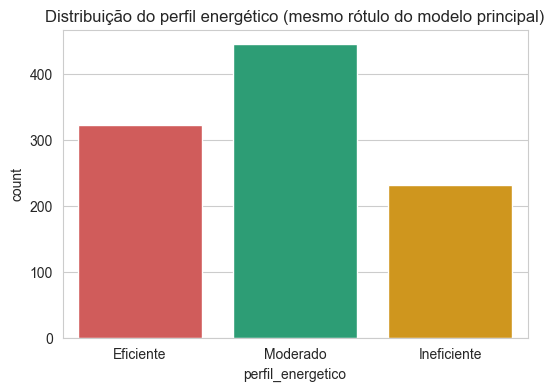

perfil_energetico
Moderado       44.5
Eficiente      32.3
Ineficiente    23.2
Name: proportion, dtype: float64

In [6]:
plt.figure(figsize=(6,4))
ordem = ['Eficiente', 'Moderado', 'Ineficiente']
sns.countplot(data=base_mvp, x='perfil_energetico', hue='perfil_energetico', order=ordem,
              palette=['#1baf7a', '#eda100', '#e34948'], legend=False)
plt.title('Distribuição do perfil energético (mesmo rótulo do modelo principal)')
plt.show()

base_mvp['perfil_energetico'].value_counts(normalize=True).round(3) * 100

In [7]:
medias_desvios = base_mvp.groupby('tipo_imovel')['consumo_kwh'].agg(['mean', 'std']).round(1)
print('Média e desvio-padrão de consumo_kwh por tipo_imovel (usados para criar o rótulo):')
print(medias_desvios)
print()
print('Alguns exemplos de linha a linha:')
base_mvp[['consumo_kwh', 'tipo_imovel', 'perfil_energetico']].head(10)

Média e desvio-padrão de consumo_kwh por tipo_imovel (usados para criar o rótulo):
                mean     std
tipo_imovel                 
Comercial     5264.4  2840.7
Industrial   13667.4  8621.7
Residencial   2391.9  2772.2

Alguns exemplos de linha a linha:


,consumo_kwh,tipo_imovel,perfil_energetico
0,1220,Residencial,Moderado
1,2120,Residencial,Moderado
2,4485,Comercial,Moderado
3,15216,Comercial,Ineficiente
4,3067,Comercial,Eficiente
5,13373,Comercial,Ineficiente
6,6142,Comercial,Moderado
7,4379,Comercial,Moderado
8,4966,Residencial,Ineficiente
9,559,Residencial,Eficiente


## 5. Treinando e comparando os 3 modelos (Random Forest, Árvore de Decisão, Regressão Logística)

Mesmos 3 algoritmos comparados no modelo principal, pelo mesmo motivo do edital
("treinamento de modelos supervisionados", no plural).

In [8]:
colunas_categoricas_mvp = ['tipo_imovel']
colunas_numericas_mvp = ['consumo_kwh', 'uso_horario_pico', 'quantidade_equipamentos', 'horas_alto_consumo']

X = base_mvp[colunas_categoricas_mvp + colunas_numericas_mvp]
y = base_mvp['perfil_energetico']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessador_mvp = ColumnTransformer(transformers=[
    ('categoria', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas_mvp),
    ('numerica', StandardScaler(), colunas_numericas_mvp),
])

In [9]:
modelos_mvp = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=2000, random_state=42),
}

resultados_mvp = {}
pipelines_mvp = {}

for nome, classificador in modelos_mvp.items():
    pipe = Pipeline(steps=[('preparador', preprocessador_mvp), ('modelo', classificador)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    resultados_mvp[nome] = {
        'acuracia': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
    }
    pipelines_mvp[nome] = pipe

    print(f'--- {nome} ---')
    print(classification_report(y_test, y_pred))

--- Random Forest ---
              precision    recall  f1-score   support

   Eficiente       1.00      0.98      0.99        65
 Ineficiente       1.00      0.96      0.98        46
    Moderado       0.97      1.00      0.98        89

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200

--- Árvore de Decisão ---
              precision    recall  f1-score   support

   Eficiente       1.00      0.98      0.99        65
 Ineficiente       1.00      0.98      0.99        46
    Moderado       0.98      1.00      0.99        89

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200

--- Regressão Logística ---
              precision    recall  f1-score   support

   Eficiente       0.90      0.98      0.94        65
 Ineficiente       0.97      0.85      0.91        46

## 6. Comparação e escolha do modelo

In [10]:
tabela_mvp = pd.DataFrame(resultados_mvp).T.sort_values('f1_macro', ascending=False)
tabela_mvp

,acuracia,f1_macro
Árvore de Decisão,0.990,0.990049
Random Forest,0.985,0.984484
Regressão Logística,0.920,0.919422


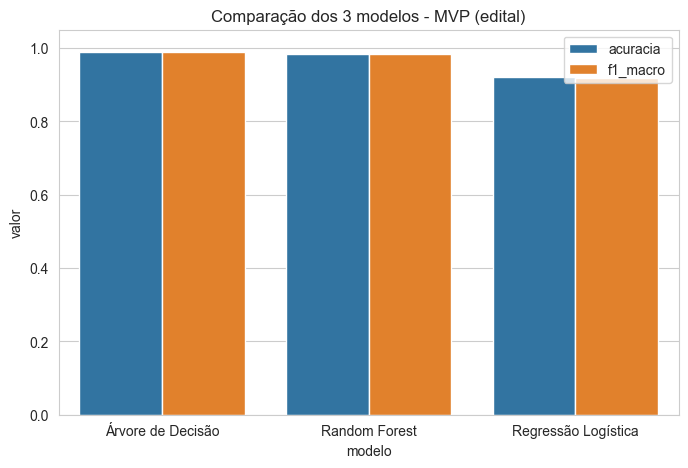

In [11]:
plt.figure(figsize=(8,5))
tabela_plot = tabela_mvp.reset_index().rename(columns={'index':'modelo'})
tabela_melt = tabela_plot.melt(id_vars='modelo', value_vars=['acuracia','f1_macro'], var_name='metrica', value_name='valor')
sns.barplot(data=tabela_melt, x='modelo', y='valor', hue='metrica')
plt.title('Comparação dos 3 modelos - MVP (edital)')
plt.ylim(0,1.05)
plt.legend(title='')
plt.show()

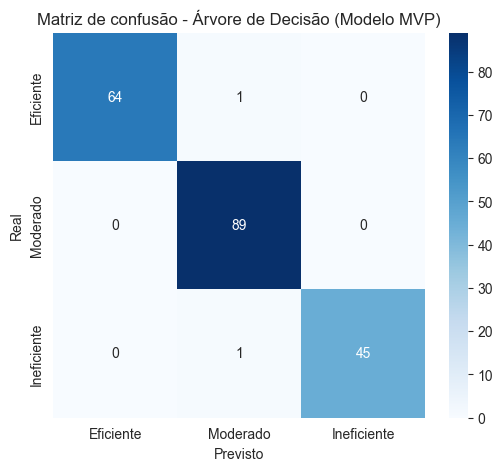

Modelo MVP escolhido: Árvore de Decisão


In [12]:
melhor_nome_mvp = tabela_mvp.index[0]
melhor_pipe_mvp = pipelines_mvp[melhor_nome_mvp]

y_pred_melhor = melhor_pipe_mvp.predict(X_test)
matriz = confusion_matrix(y_test, y_pred_melhor, labels=ordem)

plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=ordem, yticklabels=ordem)
plt.title(f'Matriz de confusão - {melhor_nome_mvp} (Modelo MVP)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

print(f'Modelo MVP escolhido: {melhor_nome_mvp}')

In [13]:
joblib.dump(melhor_pipe_mvp, 'modelo_mvp.pkl')
print(f'Modelo MVP ({melhor_nome_mvp}) salvo em modelo_mvp.pkl')

Modelo MVP (Árvore de Decisão) salvo em modelo_mvp.pkl


## 7. Exemplo de uso (igual ao exemplo do edital)

In [14]:
from prever_mvp import prever_mvp

exemplo = prever_mvp(
    consumo_kwh=420,
    uso_horario_pico=True,
    quantidade_equipamentos=10,
    tipo_imovel='Residencial',
    horas_alto_consumo=8,
    modelo=melhor_pipe_mvp,
)
exemplo

{'categoria': 'Eficiente',
 'probabilidade': np.float64(1.0),
 'recomendacoes': ['Parabéns! Seu consumo está dentro do esperado para o seu perfil. Continue assim.',
  'Evite concentrar o uso de equipamentos no horário de ponta da Light (17h30-20h30).'],
 'custo_estimado_mensal': 315.0}

## 8. Resumo

- Base MVP derivada da mesma base e do mesmo rótulo do modelo principal, só com os 5 campos do edital.
- Os 3 algoritmos (Random Forest, Árvore de Decisão, Regressão Logística) foram comparados; o
  melhor foi escolhido pela métrica F1 macro e salvo em `modelo_mvp.pkl`.
